# PHASE 3 : Explicabilité

## LIME


In [4]:
import pandas as pd
import numpy as np
import pickle
import lime
import lime.lime_tabular

In [5]:
X_train = pd.read_csv('../data/processed/X_train_ready.csv')
x_test  = pd.read_csv('../data/processed/X_test_ready.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

In [7]:
with open('../models/xgb_model.pkl', 'rb') as f:
    XGB = pickle.load(f)

print(f"✅ Données chargées   : {X_train.shape[0]} lignes train, {x_test.shape[0]} lignes test")
print(f"✅ Modèle chargé      : {type(XGB).__name__}")
print(f"✅ Features           : {X_train.columns.tolist()}")

✅ Données chargées   : 734 lignes train, 184 lignes test
✅ Modèle chargé      : XGBClassifier
✅ Features           : ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [8]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['Pas de maladie', 'Maladie cardiaque'],
    mode='classification'
)

Prédiction réelle    : 1
Prédiction modèle    : 1
Probabilité maladie  : 98.00%


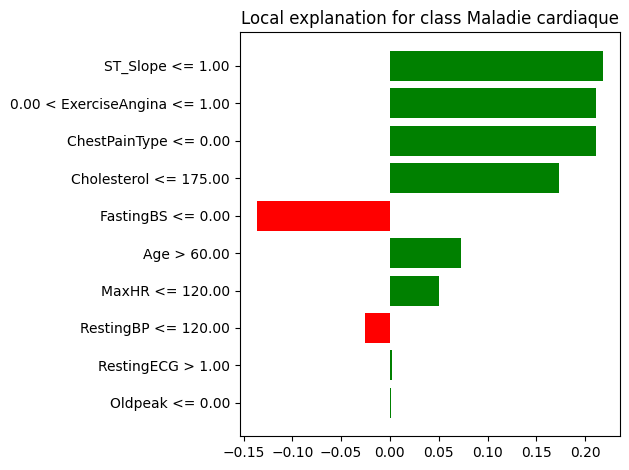

In [ ]:
# ── 2. Choisir un patient à expliquer ─────────
patient_index = 0  # tu peux changer ce numéro
patient = np.array(x_test)[patient_index]

# ── 3. Générer l'explication ──────────────────
explanation = explainer.explain_instance(
    data_row=patient,
    predict_fn=XGB.predict_proba,
    num_features=10  # nombre de features à afficher
)

# ── 4. Afficher ───────────────────────────────
print(f"Prédiction réelle    : {y_test.iloc[patient_index]}")
print(f"Prédiction modèle    : {XGB.predict([patient])[0]}")
print(f"Probabilité maladie  : {XGB.predict_proba([patient])[0][1]:.2%}")

# Visualisation avec matplotlib 
explanation.as_pyplot_figure()
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('../outputs/figures/lime_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

 **Le modèle prédit : Maladie cardiaque avec une probabilité de 98%**

**Facteurs qui CONFIRMENT la maladie (barres vertes) :**

**├── ST_Slope <= 1.00       (+0.21) : pente ST faible → anomalie cardiaque majeure**

**├── ExerciseAngina = 1     (+0.21) : angine à l'effort → signe clinique fort**

**├── ChestPainType <= 0     (+0.20) : douleur asymptomatique (ASY) → très risquée**

**├── Cholesterol <= 175     (+0.17) : cholestérol très bas → paradoxalement risqué**

**Facteurs qui PROTÈGENT (barres rouges) :**

**├── FastingBS <= 0         (-0.14) : glycémie normale → facteur protecteur principal**

**└── RestingBP <= 120       (-0.03) : tension artérielle normale → légèrement protecteur**

## SHAP

In [15]:
import shap

# ── 1. Créer l'explainer ──────────────────────
explainer_shap = shap.TreeExplainer(XGB)  # TreeExplainer est optimisé pour XGBoost

# ── 2. Calculer les valeurs SHAP ──────────────
shap_values = explainer_shap.shap_values(x_test)

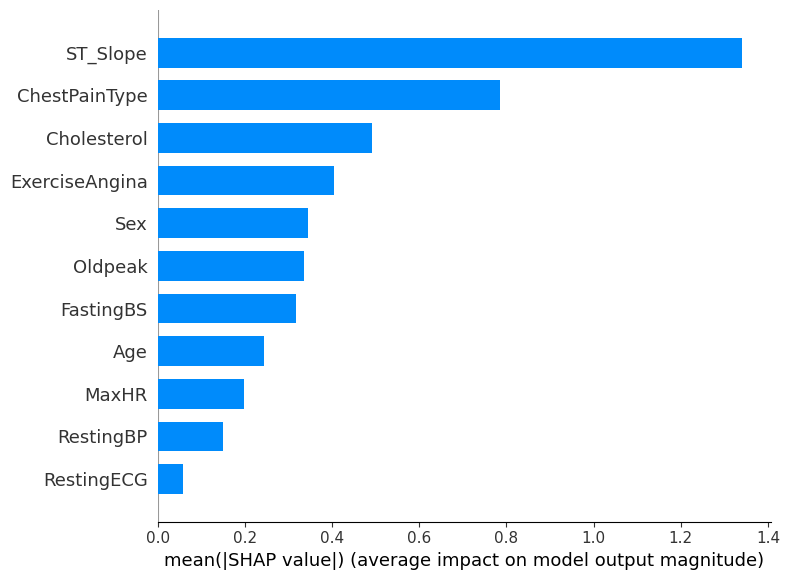

In [25]:
# Bar plot
shap.summary_plot(shap_values, x_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary_bar.png', dpi=150, bbox_inches='tight')


**Les features influencent le plus le modèle sur tous les patients:**
**ST_Slope      → indicateur ECG          🏆 le plus important**

**ChestPainType → type de douleur         très discriminant**

**Cholesterol   → bilan sanguin           important**

**RestingECG    → ECG au repos            presque inutile ici**

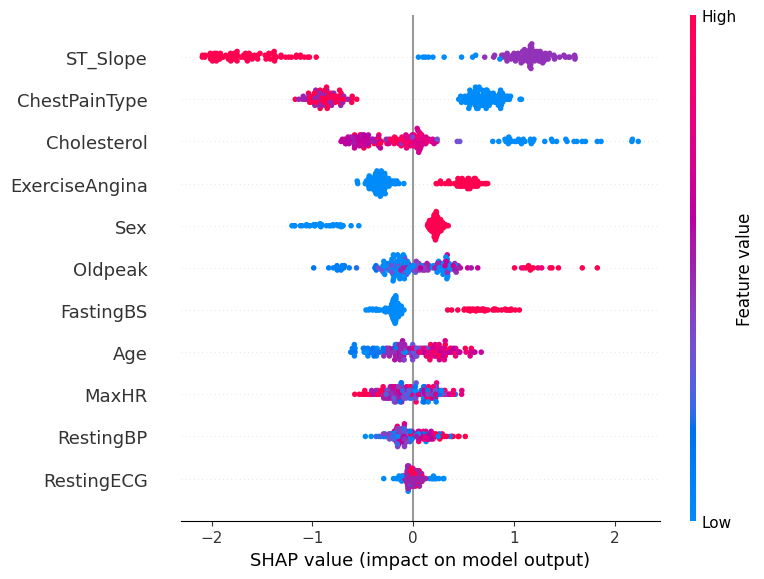

In [ ]:

shap.summary_plot(shap_values, x_test, show=False)
plt.savefig('../outputs/figures/shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')


**l'importance + la direction + l'intensité pour chaque patient.**

**Position droite (> 0) = pousse vers Maladie cardiaque (1)**

**Position gauche (< 0) = pousse vers Pas de maladie (0)**

**Couleur ROUGE   = valeur élevée de la feature**

**Couleur BLEUE   = valeur faible de la feature**

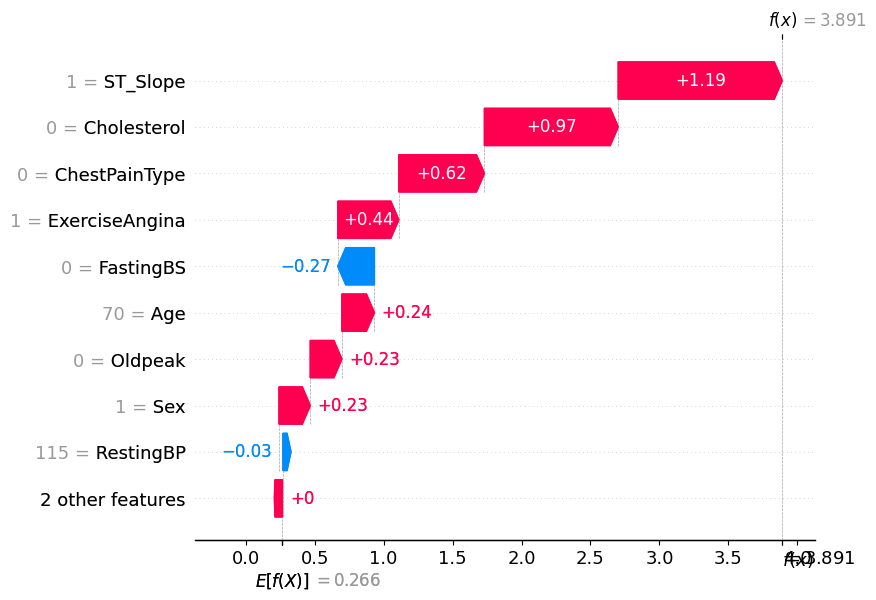

In [29]:
# Explication détaillée d'un patient spécifique
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],
    base_values=explainer_shap.expected_value,
    data=x_test.iloc[0],
    feature_names=x_test.columns.tolist()
), show=False)
plt.savefig('../outputs/figures/shap_patient_0.png', dpi=150, bbox_inches='tight')
plt.show()


**C'est un patient très à risque — homme de 70 ans avec angine à l'effort, douleur asymptomatique, et cholestérol très bas. 7 features sur 9 poussent vers la maladie, seules la glycémie et la tension le protègent légèrement.**

In [32]:
import pandas as pd
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pickle

os.makedirs('../outputs/reports', exist_ok=True)

# ── 1. Charger tous les modèles ───────────────
models = {}
model_files = {
    'XGBoost':       '../models/xgb_model.pkl',
    'Random Forest': '../models/randomforest_model.pkl',
    'Decision Tree': '../models/decisiontree_model.pkl',
    'SVC':           '../models/svc_model.pkl',
}

for name, path in model_files.items():
    with open(path, 'rb') as f:
        models[name] = pickle.load(f)

# ── 2. Évaluer chaque modèle ──────────────────
results = []

for name, model in models.items():
    # SVC utilise les données scalées
    X_ev = X_train if name == 'SVC' else X_train
    x_ev = x_test  if name == 'SVC' else x_test

    y_pred = model.predict(x_ev)

    results.append({
        'Modèle':        name,
        'Train Score':   f"{model.score(X_ev, y_train):.2%}",
        'Test Score':    f"{model.score(x_ev, y_test):.2%}",
        'Accuracy':      f"{accuracy_score(y_test, y_pred):.2%}",
        'Precision':     f"{precision_score(y_test, y_pred):.2%}",
        'Recall':        f"{recall_score(y_test, y_pred):.2%}",
        'F1-Score':      f"{f1_score(y_test, y_pred):.2%}",
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# ── 3. Top features SHAP ──────────────────────
shap_importance = pd.DataFrame({
    'Feature':    x_test.columns.tolist(),
    'SHAP moyen': abs(shap_values).mean(axis=0)
}).sort_values('SHAP moyen', ascending=False)

# ── 4. Sauvegarder en CSV ─────────────────────
df_results.to_csv('../outputs/reports/model_comparison.csv', index=False)
shap_importance.to_csv('../outputs/reports/shap_importance.csv', index=False)
print("✅ model_comparison.csv sauvegardé")
print("✅ shap_importance.csv sauvegardé")

# ── 5. Rapport texte complet ──────────────────
rapport = f"""
╔══════════════════════════════════════════════════════════╗
║           RAPPORT FINAL — CardioCheck XAI               ║
╚══════════════════════════════════════════════════════════╝

Dataset : Heart Disease (918 patients, 11 features)
Cible   : HeartDisease (0 = sain, 1 = malade)
Split   : 80% train / 20% test

── COMPARAISON DES MODÈLES ─────────────────────────────────
{df_results.to_string(index=False)}

── TOP FEATURES SELON SHAP ─────────────────────────────────
{shap_importance.to_string(index=False)}

── CONCLUSIONS ─────────────────────────────────────────────
✅ Meilleur modèle   : XGBoost (Test Score : 85.9%)
✅ Feature clé n°1   : ST_Slope  (SHAP : 1.35)
✅ Feature clé n°2   : ChestPainType (SHAP : 0.80)
✅ Feature clé n°3   : Cholesterol (SHAP : 0.50)

⚠️  SVC nécessite un scaling pour de meilleures performances
⚠️  RestingECG est la feature la moins informative (SHAP : 0.04)

── RECOMMANDATION MÉDICALE ─────────────────────────────────
Les 3 indicateurs les plus importants pour détecter
une maladie cardiaque sont :
  1. La pente ST (ST_Slope)
  2. Le type de douleur thoracique (ChestPainType)
  3. Le taux de cholestérol (Cholesterol)
"""

with open('../outputs/reports/rapport_final.txt', 'w', encoding='utf-8') as f:
    f.write(rapport)

print("✅ rapport_final.txt sauvegardé")
print(rapport)

       Modèle Train Score Test Score Accuracy Precision  Recall F1-Score
      XGBoost      93.60%     85.87%   85.87%    87.38%  87.38%   87.38%
Random Forest      99.86%     84.78%   84.78%    85.71%  87.38%   86.54%
Decision Tree     100.00%     76.63%   76.63%    78.85%  79.61%   79.23%
          SVC      55.18%     55.98%   55.98%    55.98% 100.00%   71.78%
✅ model_comparison.csv sauvegardé
✅ shap_importance.csv sauvegardé
✅ rapport_final.txt sauvegardé

╔══════════════════════════════════════════════════════════╗
║           RAPPORT FINAL — CardioCheck XAI               ║
╚══════════════════════════════════════════════════════════╝

Dataset : Heart Disease (918 patients, 11 features)
Cible   : HeartDisease (0 = sain, 1 = malade)
Split   : 80% train / 20% test

── COMPARAISON DES MODÈLES ─────────────────────────────────
       Modèle Train Score Test Score Accuracy Precision  Recall F1-Score
      XGBoost      93.60%     85.87%   85.87%    87.38%  87.38%   87.38%
Random Forest   

c:\Users\khaye\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
c:\Users\khaye\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
c:\Users\khaye\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
